# glow_waveforms.glow_pycbc: lensed waveforms in pycbc

Installing `glow_waveforms` registers its lens models with pycbc as frequency-domain approximants `GLoW_<model>`.
Such a waveform is the base approximant (default IMRPhenomXPHM) multiplied by $F^*(w)$. The lens parameters are extra
waveform arguments.

This example computes the mismatch $1-\mathcal M$ of a GW150914-like binary between the unlensed (UL) signal and
* the isolated point lens, `GLoW_PL`;
* the embedded point lens with $\kappa=\gamma$, `GLoW_PLshear_kpeqg1`. Here $(y,\theta)$ is the lens-plane offset of the microlens from the macro-image, and `g1` $=\kappa=\gamma$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pycbc.psd
from pycbc.waveform import get_fd_waveform, fd_approximants
from pycbc.filter import optimized_match

print([a for a in fd_approximants() if a.startswith('GLoW')])
# if glow_waveforms is not pip-installed: import glow_waveforms.glow_pycbc as gp; gp.register()

/home/sgoyal/miniconda3/envs/glow2_env/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


['GLoW_NFW', 'GLoW_PL', 'GLoW_PLshear', 'GLoW_PLshear_kpeqg1', 'GLoW_SIS', 'GLoW_gSIS', 'GLoW_gSISshear']


## Source and PSD
GW150914-like: 36 + 29 $M_\odot$, spins 0.4 and 0.3 with tilts 0.5 and 1.0 rad (mildly precessing), $d_L$ = 410 Mpc. The PSD is aLIGO design, with 20--1024 Hz and $\delta f=1/64$ Hz.

In [4]:
bbh = dict(mass1=36., mass2=29.,
           spin1x=0.4 * np.sin(0.5), spin1z=0.4 * np.cos(0.5),
           spin2x=0.3 * np.sin(1.0), spin2z=0.3 * np.cos(1.0),
           distance=410., inclination=0.4, coa_phase=1.3,
           f_lower=20., f_ref=20., delta_f=1. / 64, f_final=1024.)

def h_plus(approximant='IMRPhenomXPHM', **lens):
    return get_fd_waveform(approximant=approximant, **bbh, **lens)[0]

h_UL = h_plus()
psd = pycbc.psd.from_string('aLIGOZeroDetHighPower', len(h_UL), h_UL.delta_f, 15.)

def mismatch(h1, h2):
    return 1 - optimized_match(h1, h2, psd=psd, low_frequency_cutoff=20., high_frequency_cutoff=1024.)[0]

## Lensed waveforms
$M_{Lz}=10^3\,M_\odot$, $y=0.8$, and $\theta=\pi/6$ for the embedded lens.

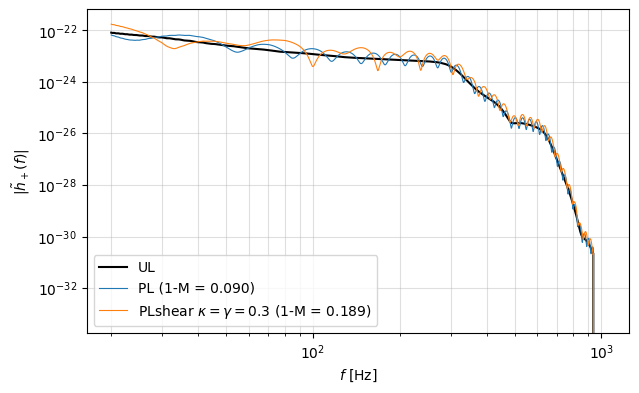

In [5]:
h_PL = h_plus('GLoW_PL', MLz=1e3, y=0.8)
h_EPL = h_plus('GLoW_PLshear_kpeqg1', MLz=1e3, y=0.8, theta=np.pi / 6, g1=0.3)

f = h_UL.sample_frequencies.numpy()
band = (f >= 20) & (f <= 1024)
plt.figure(figsize=(7, 4.2))
plt.loglog(f[band], np.abs(h_UL.numpy()[band]), 'k', label='UL')
plt.loglog(f[band], np.abs(h_PL.numpy()[band]), lw=0.8, label='PL (1-M = {:.3f})'.format(mismatch(h_PL, h_UL)))
plt.loglog(f[band], np.abs(h_EPL.numpy()[band]), lw=0.8, label=r'PLshear $\kappa=\gamma=0.3$ (1-M = {:.3f})'.format(mismatch(h_EPL, h_UL)))
plt.xlabel('$f$ [Hz]'); plt.ylabel(r'$|\tilde h_+(f)|$'); plt.legend(); plt.grid(alpha=0.4, which='both'); plt.show()

## Mismatch against $M_{Lz}$
Dashed line: $1-\mathcal M=0.02$, which is distinguishable at SNR $\approx 7$ (roughly $\rho^2(1-\mathcal M)\gtrsim1$).

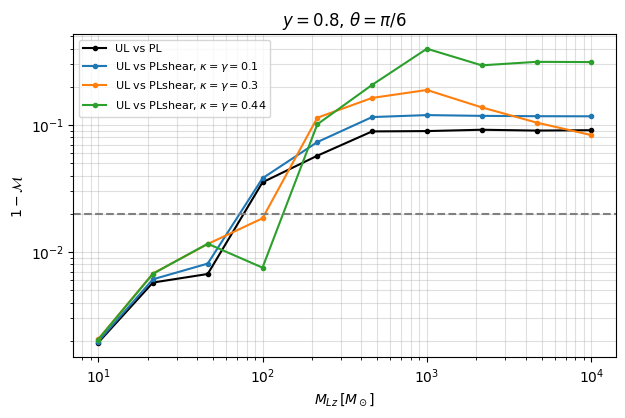

In [6]:
MLZS = np.logspace(1, 4, 10)
mm_PL = [mismatch(h_plus('GLoW_PL', MLz=M, y=0.8), h_UL) for M in MLZS]
mm_EPL = {k: [mismatch(h_plus('GLoW_PLshear_kpeqg1', MLz=M, y=0.8, theta=np.pi / 6, g1=k), h_UL) for M in MLZS]
          for k in (0.1, 0.3, 0.44)}

plt.figure(figsize=(7, 4.2))
plt.loglog(MLZS, mm_PL, 'ko-', ms=3, label=r'UL vs PL')
for k, mm in mm_EPL.items():
    plt.loglog(MLZS, mm, 'o-', ms=3, label=r'UL vs PLshear, $\kappa=\gamma={:g}$'.format(k))
plt.axhline(0.02, c='gray', ls='--')
plt.xlabel(r'$M_{Lz}\,[M_\odot]$'); plt.ylabel(r'$1-\mathcal{M}$'); plt.title(r'$y=0.8$, $\theta=\pi/6$')
plt.legend(fontsize=8); plt.grid(alpha=0.4, which='both'); plt.show()